In [5]:
import torch 
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
from torchvision import datasets, transforms

In [6]:
if torch.backends.mps.is_available():
    device=torch.device("mps")
    print("MPS found")
else:
    device=torch.device("cpu")
    print("MPS not found")

MPS found


In [7]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [8]:
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [10]:
train_dataset=datasets.ImageFolder("dataset/Training",transform=transform)
test_dataset=datasets.ImageFolder("dataset/Testing",transform=test_transform)
val_dataset=datasets.ImageFolder("dataset/Validation",transform=test_transform)

In [11]:
train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=64,shuffle=False)
val_loader=DataLoader(val_dataset,batch_size=64 ,shuffle=False)

In [12]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.cnn=nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        self.mlp=nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*16*16,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64,5),
        )
    def forward(self, features):
        out = self.cnn(features)
        out = self.mlp(out)
        return out

In [13]:
learning_rate= 1e-4
epochs=10

In [14]:
model=Model()
model=model.to(device)
criterion= nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=learning_rate,weight_decay=1e-4)

In [15]:
train_losses = []
val_losses = []

In [ ]:
max_loss=float('inf')
for epoch in range(epochs):
    model.train()
    total_loss=0
    val_loss=0
    for batch_feature,batch_label in train_loader:
        
        
        batch_feature = batch_feature.to(device)
        batch_label = batch_label.to(device)
        

        output = model(batch_feature)
        
    
        loss = criterion(output,batch_label)
        
        
        optimizer.zero_grad()
        loss.backward()
        
        
        optimizer.step()
        
        total_loss+=loss.item()
    
    
    model.eval()
    with torch.no_grad():
        for batch_feature,batch_label in val_loader:
            batch_feature=batch_feature.to(device)
            batch_label=batch_label.to(device)
            
            output = model(batch_feature)
            loss = criterion(output,batch_label)
            val_loss+=loss.item()
            
    if max_loss>val_loss/len(val_loader):
        max_loss=val_loss/len(val_loader)
        torch.save(model.state_dict(), "best.pth")
    
    print("Epoch: ", epoch+1 , "Loss of Validation: ", val_loss/len(val_loader))
    print("Epoch: ", epoch+1 , "Loss of Training: ", total_loss/len(train_loader)) 
    train_losses.append(total_loss/len(train_loader))
    val_losses.append(val_loss/len(val_loader))       

Epoch:  1 Loss of Validation:  0.3519032978829706
Epoch:  1 Loss of Training:  0.6337269147634507
Epoch:  2 Loss of Validation:  0.24812737320705006
Epoch:  2 Loss of Training:  0.38018724697828293
Epoch:  3 Loss of Validation:  0.18705414347202767
Epoch:  3 Loss of Training:  0.2930700493454933
Epoch:  4 Loss of Validation:  0.15472038799623353
Epoch:  4 Loss of Training:  0.23581239338219165
Epoch:  5 Loss of Validation:  0.1407414925980404
Epoch:  5 Loss of Training:  0.20561650696396827
Epoch:  6 Loss of Validation:  0.12814100482716193
Epoch:  6 Loss of Training:  0.1813899590522051
Epoch:  7 Loss of Validation:  0.11212861845244392
Epoch:  7 Loss of Training:  0.1572793798595667
Epoch:  8 Loss of Validation:  0.0976625560087707
Epoch:  8 Loss of Training:  0.14381638020277024
Epoch:  9 Loss of Validation:  0.08227490381885594
Epoch:  9 Loss of Training:  0.13075255540013314
Epoch:  10 Loss of Validation:  0.12473420568583982
Epoch:  10 Loss of Training:  0.12752745995670556


In [17]:
total_train=0
count_train=0
model.load_state_dict(torch.load("best.pth"))
model.to(device)
model.eval()
with torch.no_grad():
    for batch_feature,batch_label in train_loader:
        batch_feature=batch_feature.to(device)
        batch_label=batch_label.to(device)
        
        output = model(batch_feature)
        
        _,indices=torch.max(output,1)
        total_train+=batch_label.shape[0]
        count_train+= (indices==batch_label).sum().item()
    print("Accuracy of training of model is ", count_train/total_train)

Accuracy of training of model is  0.9696875


In [18]:
true_labels=[]
predicted_labels=[]
total_test=0
count_test=0
model.load_state_dict(torch.load("best.pth"))
model.to(device)
model.eval()
with torch.no_grad():
    for batch_feature,batch_label in test_loader:
        batch_feature=batch_feature.to(device)
        batch_label=batch_label.to(device)
        
        output = model(batch_feature)
        
        _,indices=torch.max(output,1)
        total_test+=batch_label.shape[0]
        count_test+= (indices==batch_label).sum().item()
        
        predicted_labels.extend(indices.cpu().numpy())
        true_labels.extend(batch_label.cpu().numpy())
    print("Accuracy of testing of model is ", count_test/total_test)

Accuracy of testing of model is  0.9616


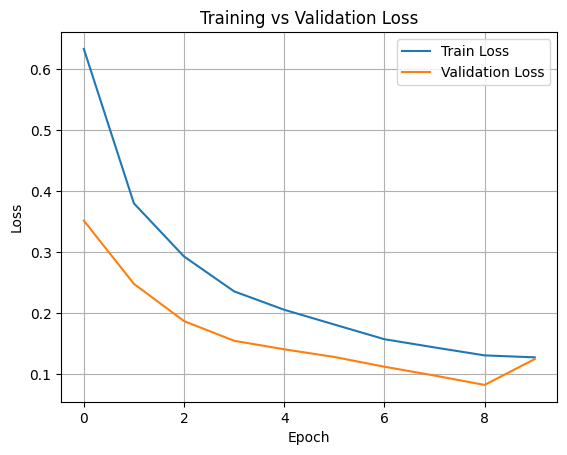

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

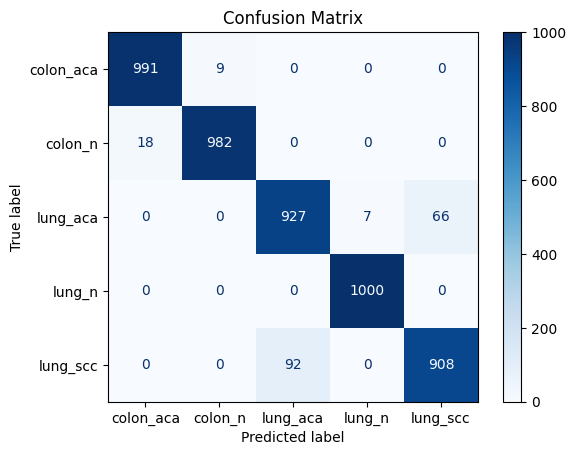

In [20]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = test_loader.dataset.classes
cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [21]:
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

   colon_aca       0.98      0.99      0.99      1000
     colon_n       0.99      0.98      0.99      1000
    lung_aca       0.91      0.93      0.92      1000
      lung_n       0.99      1.00      1.00      1000
    lung_scc       0.93      0.91      0.92      1000

    accuracy                           0.96      5000
   macro avg       0.96      0.96      0.96      5000
weighted avg       0.96      0.96      0.96      5000



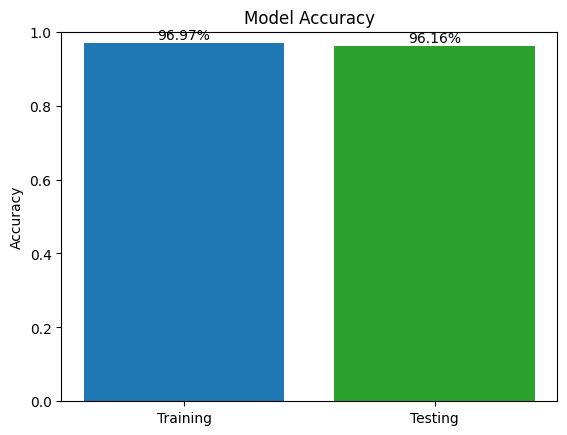

In [22]:
import matplotlib.pyplot as plt
train_acc = count_train/total_train   # from your evaluation cell
test_acc = count_test/total_test
accuracies = [train_acc, test_acc]
labels = ["Training", "Testing"]
plt.bar(labels, accuracies, color=['#1f77b4','#2ca02c'])
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.ylim(0,1)
for i,v in enumerate(accuracies):
    plt.text(i, v+0.01, f"{v:.2%}", ha='center')
plt.savefig("accuracy_bar.png", dpi=150, bbox_inches="tight")
plt.show()